In [8]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config
from halo_model.halos.base.profile.profile import CompositeProfile

In [9]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010_mod import ClumpMassGiocoli2010_mod
from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.tinker2008 import MassFuncTinker2008

from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellarpowerlaw import ProfileStellarPowerLaw
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass


from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO

from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013

from halo_model.power_spectra.Pm_computer import Pm_computer

In [10]:
cfg = Config()
cfg.z = 2

c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationPieri2009_clumps(c_smooth, d_vir=0.3)

mass_func = MassFuncTinker2008(cfg)

shmr_smooth = SMHRMoster2013(cfg, c_smooth)

smooth_profile = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile = ProfileNFW(c_clump, R_virSO(cfg))

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_smooth, R_virSO(cfg))

In [ ]:
cfg_local = copy.deepcopy(cfg)

clump_mass_func = ClumpMassGiocoli2010(cfg_local)

def w_star(cosmo, M, z):
    return shmr_smooth(cosmo, M, z) # contribution from stars in central
def w_smooth(cosmo, M, z):
    return (
        (1 - clump_mass_func.f(M)) * (1 - shmr_smooth(cosmo, M, z)) # contribution from dm in smooth component:
        #+ clump_mass_func.f(M)* shmr_smooth(cosmo, M, z) # contribution from stars in clumps (traces the dm component)
        )

smooth_profile_wstellar = CompositeProfile(
    smooth_profile, ProfilePointMass(),
    weights=[w_smooth, w_star]
)

Pm_std = MatterPower(cfg_local, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile_wstellar, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg_local.k_min), np.log10(cfg_local.k_max), cfg_local.N_k)

dict_std = Pm_computer(Pm_std, k_vals)
    

interpolating Ic and Jc functions...


In [ ]:
k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_m0s = []

for m0 in [2e9]: #[1e7, 1e8, 1e9, 1e10]:
    cfg_local = copy.deepcopy(cfg)
    cfg_local.m0 = m0
    cfg_local.beta = -1
    clump_mass_func_mod = ClumpMassGiocoli2010_mod(cfg_local)
    
    def w_star(cosmo, M, z):
        return shmr_smooth(cosmo, M, z) # contribution from stars in central
    def w_smooth(cosmo, M, z):
        return (
            (1 - clump_mass_func_mod.f(M)) * (1 - shmr_smooth(cosmo, M, z)) # contribution from dm in smooth component:
            #+ clump_mass_func_mod.f(M) * shmr_smooth(cosmo, M, z) # contribution from stars in clumps (traces the dm component)
            )

    smooth_profile_wstellar = CompositeProfile(
        smooth_profile, ProfilePointMass(),
        weights=[w_smooth, w_star]
    )

    Pm = MatterPower(cfg_local, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile_wstellar, 
                 bias=bias,
                 clump_mass_func=clump_mass_func_mod, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)
    
    Pm_m0s.append(Pm)

P_m0_dicts = []

for Pm in Pm_m0s:
    P_m0_dicts.append(Pm_computer(Pm, k_vals))


interpolating Ic and Jc functions...


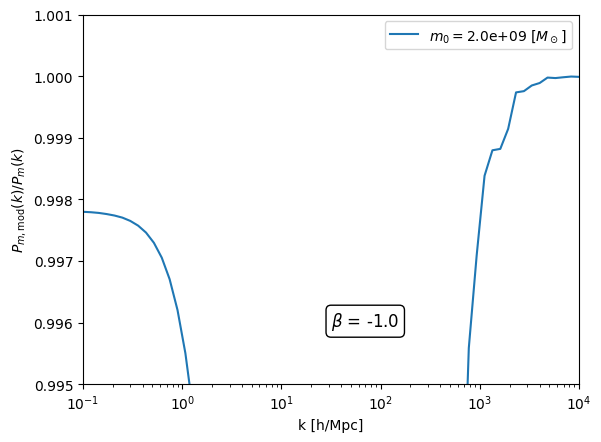

In [15]:
for i, dict_ in enumerate(P_m0_dicts):
    plt.plot(k_vals, dict_['P_tot']/dict_std['P_tot'], label=r'$m_0 =$' + f'{Pm_m0s[i].cfg.m0:.1e} ' +r'$[M_\odot$]')
        
plt.xscale("log")
plt.ylim(0.995, 1.001)
plt.xlim(np.min(k_vals), np.max(k_vals))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()

plt.text(
    0.5, 0.2,
    r"$\beta$" +  f" = {Pm_m0s[i].cfg.beta:.1f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)

plt.savefig("plots_Pm_modified_cmf/Pm_mod_m0.pdf")
plt.show()

In [14]:
k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_betas = []

for beta in [-0.1, -0.3, -0.5, -1]:
    cfg_local = copy.deepcopy(cfg)
    cfg_local.m0 = 2e9
    cfg_local.beta = beta

    clump_mass_func = ClumpMassFuncGiocoli2010_mod(cfg_local.m0, beta=cfg_local.beta)

    Pm = MatterPower(cfg_local, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)
    
    Pm_betas.append(Pm)
    
P_beta_dicts = []

for Pm in Pm_betas:
    P_beta_dicts.append(Pm_computer(Pm, k_vals))

NameError: name 'ClumpMassFuncGiocoli2010_mod' is not defined

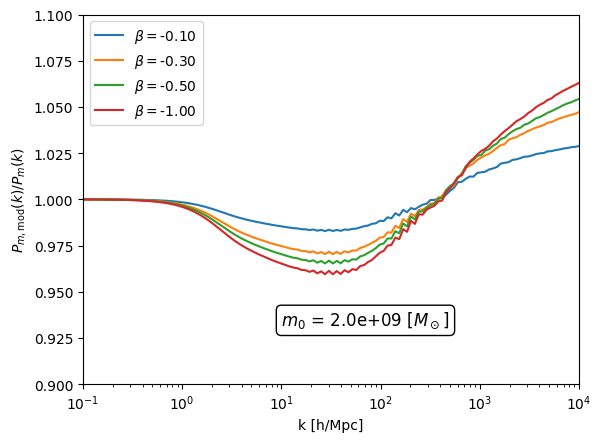

In [ ]:
for i, dict_ in enumerate(P_beta_dicts):

    plt.plot(k_vals, dict_['P_1h']/dict_std['P_1h'], label=r'$\beta =$' + f'{Pm_betas[i].cfg.beta:.2f}')
        
plt.xscale("log")
plt.ylim(0.9, 1.1
         )
plt.xlim(np.min(k_vals), np.max(k_vals))
plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{mod}}(k) / P_m(k)$')
plt.legend()

plt.text(
    0.4, 0.2,
    r"$m_0$" +  f" = {Pm_betas[i].cfg.m0:.1e} " + r"$[M_\odot]$",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=1)
)
plt.savefig("plots_Pm_modified_cmf/Pm_mod_beta.pdf")
plt.show()